In [78]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [79]:
df = pd.read_csv('weight-height.csv')

In [80]:
df.shape

(10000, 3)

In [81]:
df.head(5)

,Gender,Height,Weight
0,Male,73.847017,241.893563
1,Male,68.781904,162.310473
2,Male,74.110105,212.740856
3,Male,71.730978,220.042470
4,Male,69.881796,206.349801


In [82]:
X = df[['Height']]
y = df['Weight']

In [83]:
y.head(5)

0    241.893563
1    162.310473
2    212.740856
3    220.042470
4    206.349801
Name: Weight, dtype: float64

In [84]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [85]:
# Standarization
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [86]:
from sklearn.linear_model import LinearRegression

regressor = LinearRegression()

In [87]:
regressor.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[29.62]
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,161.3
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,1
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](1,)",[89.44]


In [88]:
print(regressor.intercept_)
print(regressor.coef_)

161.3267623130613
[29.61903439]


In [89]:
y_predict = regressor.predict(X_test)

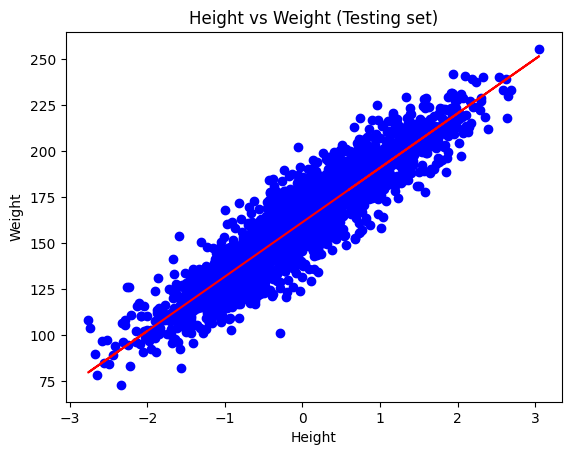

In [90]:
plt.scatter(X_test, y_test, color='blue')
plt.plot(X_test, y_predict, color='red') 
plt.title('Height vs Weight (Testing set)')
plt.xlabel('Height')
plt.ylabel('Weight')
plt.show()

In [91]:
y_train_predict = regressor.predict(X_train)

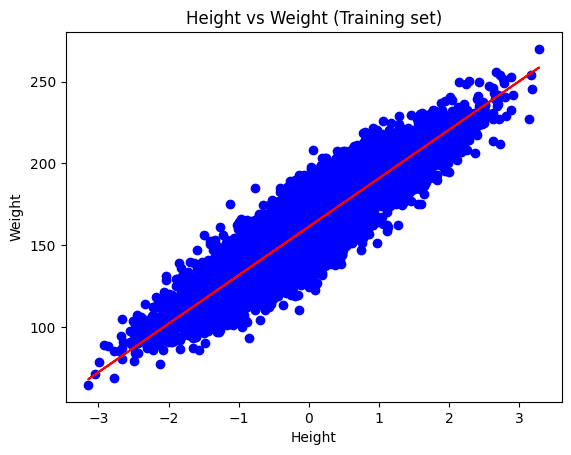

In [92]:
plt.scatter(X_train, y_train, color='blue')
plt.plot(X_train, y_train_predict, color='red') 
plt.title('Height vs Weight (Training set)')
plt.xlabel('Height')
plt.ylabel('Weight')
plt.show()

In [93]:
new_height = np.array([[70]])
new_height_scaled = scaler.transform(new_height)
predicted_weight = regressor.predict(new_height_scaled)

/Users/nayan/ml/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


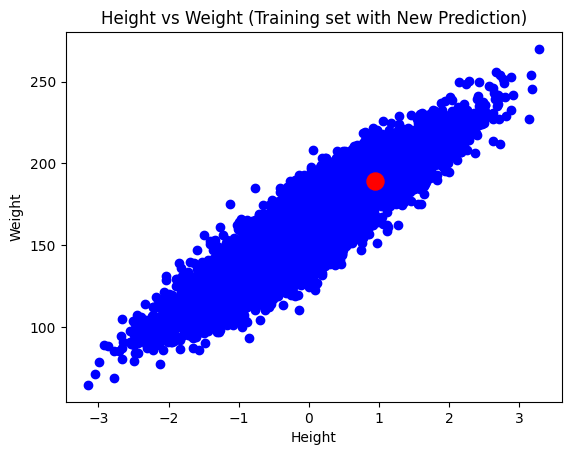

In [94]:
# 1. Plot your training data
plt.scatter(X_train, y_train, color='blue')

# 2. Plot your single new prediction point (Green marker)
plt.scatter(new_height_scaled, predicted_weight, color='red', s=150) 

# 3. Add labels and show
plt.title('Height vs Weight (Training set with New Prediction)')
plt.xlabel('Height')
plt.ylabel('Weight')
plt.show()

In [95]:
from sklearn.metrics import mean_squared_error, r2_score

mse = mean_squared_error(y_test, y_predict)
r2 = r2_score(y_test, y_predict)

In [96]:
print("Mean Squared Error:", mse)
print("R^2 Score:", r2)

Mean Squared Error: 149.00350418448116
R^2 Score: 0.85773177770385


In [97]:
import joblib
joblib.dump(regressor, 'linear_regression_model.pkl')
joblib.dump(scaler, 'scaler.pkl')

['scaler.pkl']

In [98]:
regressor_loaded = joblib.load('linear_regression_model.pkl')
scaler_loaded = joblib.load('scaler.pkl')